# Globale Kindersterblichkeit und ihre Ursachen


### Fragestellungen:

- 1. Welche fünf markanten globalen „Brüche“ (Ausschläge und starke Rückgänge) in der Kindersterblichkeit lassen sich im 20. und 21. Jahrundert identifizieren und wie hängen diese "Brüche" mit konkreten historischen Ereignissen zusammen?

- 2. Wie hängen Kindersterblichkeitsrate und Geburtenrate auf kontinentaler Ebene zusammen und wie verändert sich dieser Zusammenhang im Zeitverlauf?

- 3. Wie stark unterscheiden sich die Kindersterblichkeitsraten innerhalb der Kontinente und wie hat sich diese innerkontinentale Ungleichheit im Laufe der Zeit verändert?

- 4. Wie stellt sich das in der Schweiz dar (Fragestellung 1 und 2)?


### Datenquellen:
- https://ourworldindata.org/grapher/child-mortality

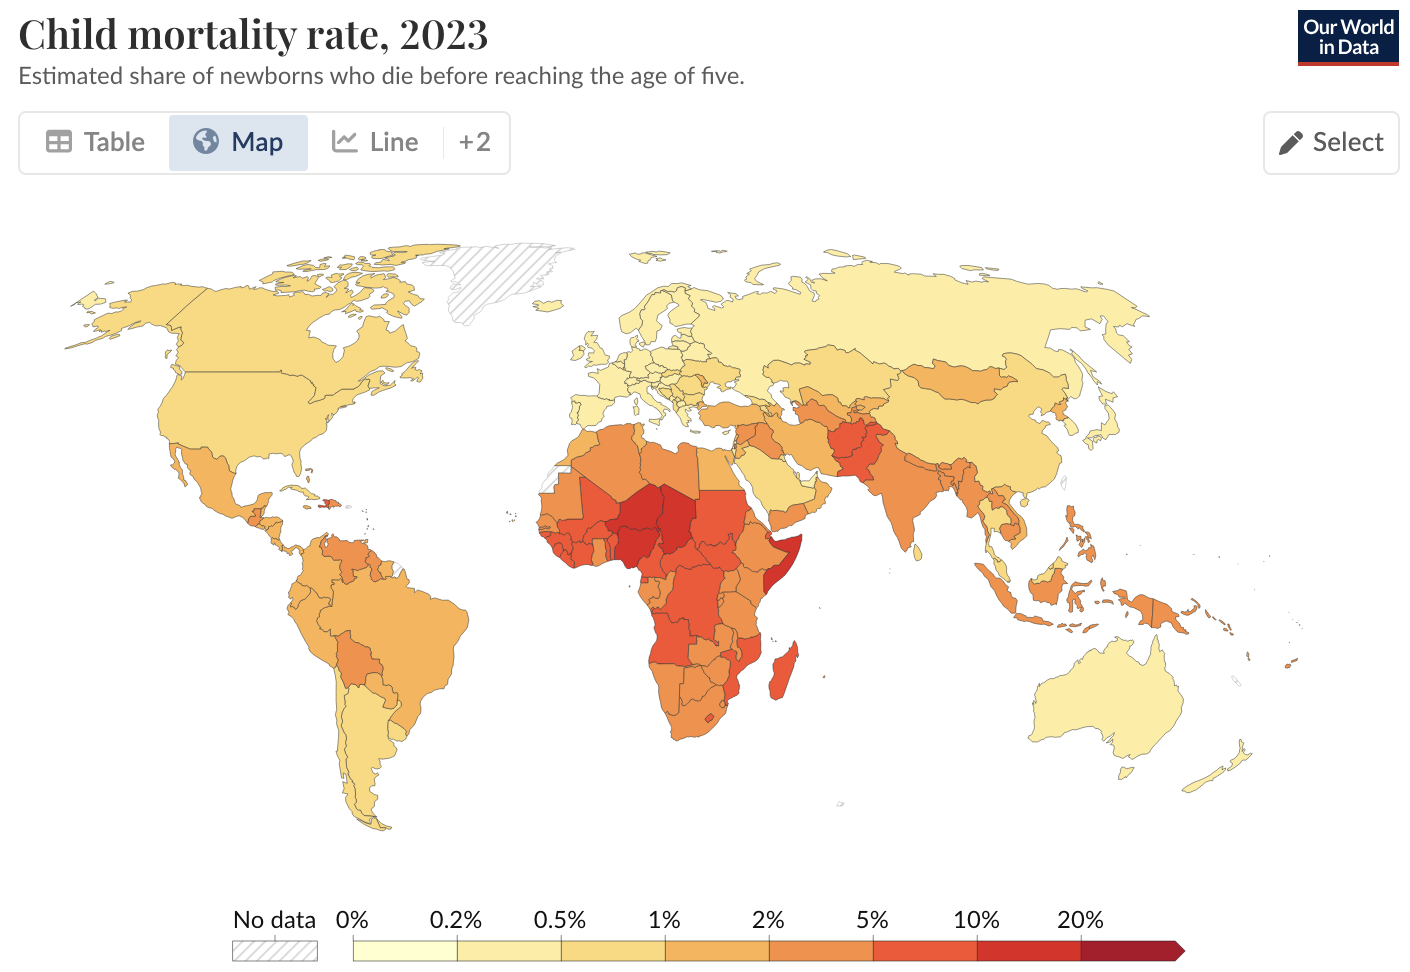

In [178]:
# Titelbild einfügen
from IPython.display import Image, display
bildpfad = "../resources/child mortality rate 2023.jpg"

display(Image(filename=bildpfad))


## 1. Daten beschaffen und laden

In [179]:
import pandas as pd

# CSV laden
df = pd.read_csv("../data/child-mortality.csv")

# Ersten Blick auf die Daten werfen
display(df.head())

# Datentypen und Nicht-Null-Werte
df.info()

# Spaltennamen anzeigen
print("Spaltennamen:")
print(df.columns.tolist())

# Fehlende Werte überprüfen
print("\nFehlende Werte:")
print(df.isna().sum())


,Entity,Code,Year,Child mortality rate
0,Afghanistan,AFG,1957,37.13
1,Afghanistan,AFG,1958,36.52
2,Afghanistan,AFG,1959,35.95
3,Afghanistan,AFG,1960,35.32
4,Afghanistan,AFG,1961,34.76


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16835 entries, 0 to 16834
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Entity                16835 non-null  object 
 1   Code                  16217 non-null  object 
 2   Year                  16835 non-null  int64  
 3   Child mortality rate  16835 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 526.2+ KB
Spaltennamen:
['Entity', 'Code', 'Year', 'Child mortality rate']

Fehlende Werte:
Entity                    0
Code                    618
Year                      0
Child mortality rate      0
dtype: int64


## 2. Daten bereinigen und vorbereiten

In [180]:
# Spalten umbenennen
df.rename(columns={
    "Entity": "Land",
    "Code": "ISO",
    "Year": "Jahr",
    "Child mortality rate": "Kindersterblichkeit"
}, inplace=True)

# Jahr als Integer (zur Sicherheit)
df["Jahr"] = df["Jahr"].astype(int)

# Echte Kontinente (wie von OWID verwendet)
echte_kontinente = [
    "Africa", "Asia", "Europe", "North America", "South America", "Oceania"
]

# Neue Kategorie: Land / Kontinent / Region
def bestimme_ebene(row):
    if row["Land"] in echte_kontinente:
        return "Kontinent"
    elif pd.notna(row["ISO"]):
        return "Land"
    else:
        return "Region"

df["Ebene"] = df.apply(bestimme_ebene, axis=1)

# Nach Ebene, Land, Jahr sortieren
df.sort_values(["Ebene", "Land", "Jahr"], inplace=True)
df.reset_index(drop=True, inplace=True)

# Vorschau
display(df.head())

# Kurze Übersicht
print(f"Gesamtzeilen: {len(df)}")
print(f"Anzahl Länder: {df[df['Ebene'] == 'Land']['Land'].nunique()}")
print(f"Kontinente/Regionen: {df[df['Ebene'] == 'Kontinent']['Land'].unique()}")


,Land,ISO,Jahr,Kindersterblichkeit,Ebene
0,Africa,NaN,1966,25.95,Kontinent
1,Africa,NaN,1967,25.34,Kontinent
2,Africa,NaN,1968,24.73,Kontinent
3,Africa,NaN,1969,24.39,Kontinent
4,Africa,NaN,1970,24.00,Kontinent


Gesamtzeilen: 16835
Anzahl Länder: 202
Kontinente/Regionen: ['Africa' 'Asia' 'Europe' 'North America' 'Oceania' 'South America']


In [181]:
df[df["Land"] == "World"][["Land", "Ebene"]].drop_duplicates()


,Land,Ebene
16164,World,Land


## 3. Rohdatenanalyse

### 3.1 Pivottabelle

In [182]:
# Pivot-Tabelle: Land als Zeile, Jahr als Spalte, Kindersterblichkeit als Wert
pivot_df = df.pivot_table(
    index="Land",
    columns="Jahr",
    values="Kindersterblichkeit"
)

# Ergebnis anzeigen
pivot_df.head()


Jahr,1751,1752,1753,1754,1755,1756,1757,1758,1759,1760,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
Land,,,,,,,,,,,,,,,,,,,,,
Afghanistan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,7.51,7.24,7.00,6.76,6.54,6.33,6.13,5.93,5.74,5.55
Africa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,7.68,7.49,7.31,7.17,6.83,6.66,6.43,6.27,6.22,5.91
Albania,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.99,0.96,0.94,0.93,0.93,0.94,0.94,0.95,0.94,0.94
Algeria,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.54,2.49,2.45,2.40,2.37,2.33,2.29,2.26,2.23,2.20
Andorra,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.37,0.35,0.34,0.32,0.31,0.30,0.29,0.28,0.27,0.26


In [183]:
# Pivot-Tabelle mit MultiIndex in Spalten (automatisch bei pivot_table)
pivot_df = df.pivot_table(
    index="Land",
    columns="Jahr",
    values="Kindersterblichkeit"
).round(1)

# CSS für Sticky Header (erste 2 Zeilen) & erste Spalte
from IPython.display import display, HTML

style = """
<style>
.scroll-table-wrapper {
    max-height: 400px;
    overflow: auto;
    border: 1px solid #ccc;
    margin-top: 10px;
    font-family: sans-serif;
    background-color: white;
}
.scroll-table {
    border-collapse: collapse;
    width: max-content;
    min-width: 100%;
    background-color: white;
    color: black;
    font-size: 13px;
}
.scroll-table th, .scroll-table td {
    border: 1px solid #ccc;
    padding: 6px 12px;
    text-align: right;
    white-space: nowrap;
    color: black;
    background-color: white;
}
.scroll-table thead th {
    background-color: #eaeaea;
    position: sticky;
    top: 0;
    z-index: 3;
}
.scroll-table thead tr:nth-child(2) th {
    top: 28px; /* Höhe der ersten Header-Zeile */
    z-index: 3;
}
.scroll-table td:first-child,
.scroll-table th:first-child {
    position: sticky;
    left: 0;
    background-color: #f0f0f0;
    text-align: left;
    z-index: 2;
}
</style>
"""

# HTML-Tabelle generieren (MultiIndex → erzeugt 2 Header-Zeilen)
html_table = pivot_df.to_html(classes="scroll-table", border=0)

# Ausgabe im Notebook
html_output = f"""
{style}
<div class="scroll-table-wrapper">
    {html_table}
</div>
"""

display(HTML(html_output))


Jahr,1751,1752,1753,1754,1755,1756,1757,1758,1759,1760,1761,1762,1763,1764,1765,1766,1767,1768,1769,1770,1771,1772,1773,1774,1775,1776,1777,1778,1779,1780,1781,1782,1783,1784,1785,1786,1787,1788,1789,1790,1791,1792,1793,1794,1795,1796,1797,1798,1799,1800,1801,1802,1803,1804,1805,1806,1807,1808,1809,1810,1811,1812,1813,1814,1815,1816,1817,1818,1819,1820,1821,1822,1823,1824,1825,1826,1827,1828,1829,1830,1831,1832,1833,1834,1835,1836,1837,1838,1839,1840,1841,1842,1843,1844,1845,1846,1847,1848,1849,1850,1851,1852,1853,1854,1855,1856,1857,1858,1859,1860,1861,1862,1863,1864,1865,1866,1867,1868,1869,1870,1871,1872,1873,1874,1875,1876,1877,1878,1879,1880,1881,1882,1883,1884,1885,1886,1887,1888,1889,1890,1891,1892,1893,1894,1895,1896,1897,1898,1899,1900,1901,1902,1903,1904,1905,1906,1907,1908,1909,1910,1911,1912,1913,1914,1915,1916,1917,1918,1919,1920,1921,1922,1923,1924,1925,1926,1927,1928,1929,1930,1931,1932,1933,1934,1935,1936,1937,1938,1939,1940,1941,1942,1943,1944,1945,1946,1947,1948,1949,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
Land,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Afghanistan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37.1,36.5,36.0,35.3,34.8,34.2,33.7,33.2,32.6,32.2,31.7,31.2,30.6,30.2,29.6,29.1,28.6,28.1,27.5,27.0,26.4,25.8,25.2,24.6,23.9,28.0,27.4,30.9,30.1,25.3,24.7,21.8,18.7,18.1,17.4,16.8,16.3,15.8,15.3,14.8,14.4,14.0,13.6,13.2,12.7,12.3,11.9,11.4,11.0,10.5,10.1,9.6,9.2,8.8,8.5,8.1,7.8,7.5,7.2,7.0,6.8,6.5,6.3,6.1,5.9,5.7,5.6
Africa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,26.0,25.3,24.7,24.4,24.0,23.6,23.3,22.8,22.0,21.5,20.7,20.2,19.7,19.2,18.8,18.3,17.9,18.3,17.9,17.4,17.0,16.2,16.2,15.6,15.4,15.5,15.4,14.9,14.8,14.4,14.2,13.9,13.7,13.2,12.8,12.3,11.9,11.4,11.0,10.6,10.1,9.7,9.3,9.1,8.6,8.5,8.1,7.8,7.7,7.5,7.3,7.2,6.8,6.7,6.4,6.3,6.2,5.9
Albania,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N

### 3.2 Pivottabelle mit Heatmap 

In [184]:
%pip install jinja2


Note: you may need to restart the kernel to use updated packages.


In [185]:
from IPython.display import display, HTML

# Pivot-Tabelle: Länder als Zeilen, Jahre als Spalten
pivot_df = df.pivot_table(
    index="Land",
    columns="Jahr",
    values="Kindersterblichkeit"
).round(1)

# Heatmap
styled = pivot_df.style.background_gradient(
    cmap='OrRd',    # Orange-Rot-Farbverlauf
    axis=None
).format("{:.1f}")

# HTML-Rendern
styled_html = styled.to_html()

# CSS für scrollbaren Container
scroll_style = """
<style>
.scroll-wrapper {
    max-height: 400px;
    overflow: auto;
    border: 1px solid #ccc;
    font-family: sans-serif;
    font-size: 13px;
}
</style>
"""

display(HTML(scroll_style + f'<div class="scroll-wrapper">{styled_html}</div>'))


### 3.3 Rohdatenanalyse

1. Wie viele Länder sind enthalten?

In [186]:
anzahl_laender = df[df["Ebene"] == "Land"]["Land"].nunique()
print(f"Anzahl Länder im Datensatz: {anzahl_laender}")


Anzahl Länder im Datensatz: 202


2. Welche Kontinente sind enthalten?

In [187]:
# Echte Kontinente definieren
echte_kontinente = [
    "Africa",
    "Asia",
    "Europe",
    "North America",
    "Oceania",
    "South America"
]

In [188]:
# Kontinente filtern
kontinente = [k for k in echte_kontinente if k in df["Land"].unique()]
print("\nKontinente im Datensatz:")
for k in kontinente:
    print("•", k)

print("\nAnzahl Kontinente:", len(kontinente))



Kontinente im Datensatz:
• Africa
• Asia
• Europe
• North America
• Oceania
• South America

Anzahl Kontinente: 6


3. Welche sonstigen statistischen Zonen sind enthalten?

In [189]:
regionen = df[
    df["ISO"].isna() & ~df["Land"].isin(kontinente)
]["Land"].unique()

print("\nStatistische Regionen im Datensatz:")
for r in sorted(regionen):
    print("•", r)

print("\nAnzahl statistischer Regionen:", len(regionen))


Statistische Regionen im Datensatz:
• European Union (27)
• High-income countries
• Low-income countries
• Lower-middle-income countries
• Upper-middle-income countries

Anzahl statistischer Regionen: 5


### 3.4 Datenspanne

1. Zwischen welchen Jahren sind Daten enthalten?

In [190]:
min_jahr = df["Jahr"].min()
max_jahr = df["Jahr"].max()

print(f"Der Datensatz enthält Werte von {min_jahr} bis {max_jahr}.")


Der Datensatz enthält Werte von 1751 bis 2023.


2. Zwischen welchen Jahren sind Daten für Kontinente und statistische Zonen enthalten?

In [191]:
# Nur Länder
df_länder = df[df["Ebene"] == "Land"]

# Pivot: Länder = Zeilen, Jahre = Spalten
pivot_länder = df_länder.pivot_table(
    index="Land",
    columns="Jahr",
    values="Kindersterblichkeit"
)

# Zähle pro Jahr, wie viele Länder gültige Werte haben
anzahl_daten_pro_jahr = pivot_länder.notna().sum(axis=0)

# Gesamtanzahl Länder
anzahl_länder = pivot_länder.shape[0]

# Jahre, in denen ALLE Länder Daten haben
vollständige_jahre = anzahl_daten_pro_jahr[anzahl_daten_pro_jahr == anzahl_länder]

if not vollständige_jahre.empty:
    erstes_jahr = vollständige_jahre.index.min()
    print(f"Alle Länder haben ab dem Jahr {erstes_jahr} vollständige Daten.")
else:
    print("Es gibt kein Jahr, in dem alle Länder gleichzeitig Daten haben.")


Alle Länder haben ab dem Jahr 1985 vollständige Daten.


In [192]:
# Hilfslisten zur Abgrenzung
echte_kontinente = [
    "Africa", "Asia", "Europe", "North America", "South America", "Oceania"
]

# Alle Namen mit fehlendem ISO (sind keine Länder)
df_nicht_länder = df[df["ISO"].isna()]

# 1. Kontinente
df_kontinente = df[df["Land"].isin(echte_kontinente)]
min_jahr_kontinente = df_kontinente["Jahr"].min()
max_jahr_kontinente = df_kontinente["Jahr"].max()

# 2. Regionen (nicht Land, nicht Kontinent)
regionen = df_nicht_länder[~df_nicht_länder["Land"].isin(echte_kontinente)]
min_jahr_regionen = regionen["Jahr"].min()
max_jahr_regionen = regionen["Jahr"].max()

print(f"Kontinente: Daten von {min_jahr_kontinente} bis {max_jahr_kontinente}")
print(f"Statistische Regionen: Daten von {min_jahr_regionen} bis {max_jahr_regionen}")


Kontinente: Daten von 1949 bis 2023
Statistische Regionen: Daten von 1968 bis 2023


3. Ab welchem Jahr sind Daten für alle Länder verfügbar?

In [193]:
# Nur Länder berücksichtigen
df_l = df[df["Ebene"] == "Land"].copy()

# Pivot-Tabelle: Länder als Zeilen, Jahre als Spalten
pivot = df_l.pivot_table(
    index="Land",
    columns="Jahr",
    values="Kindersterblichkeit"
)

# Anzahl Länder insgesamt
anzahl_laender = pivot.shape[0]

# Für jedes Jahr: wie viele Länder haben Werte?
verfuegbar_pro_jahr = pivot.notna().sum(axis=0)

# Jahre mit vollständiger Abdeckung
vollstaendige_jahre = verfuegbar_pro_jahr[verfuegbar_pro_jahr == anzahl_laender]

if not vollstaendige_jahre.empty:
    erstes_jahr = int(vollstaendige_jahre.index.min())
    print(f"Für alle Länder liegen ab dem Jahr {erstes_jahr} vollständige Daten vor.")
else:
    print("Es gibt kein Jahr, in dem für alle Länder Daten vorliegen.")


Für alle Länder liegen ab dem Jahr 1985 vollständige Daten vor.


4. Welches Land hat die meisten und welches die wenigsten Datenpunkte?

In [194]:
# Nur Länder analysieren
df_länder = df[df["Ebene"] == "Land"]

# Zähle Anzahl gültiger Werte pro Land
datenpunkte_pro_land = df_länder.groupby("Land")["Kindersterblichkeit"].apply(lambda x: x.notna().sum())

# Land mit meisten Datenpunkten
land_max = datenpunkte_pro_land.idxmax()
anz_max = datenpunkte_pro_land.max()

# Land mit wenigsten Datenpunkten (>0)
datenpunkte_positiv = datenpunkte_pro_land[datenpunkte_pro_land > 0]
land_min = datenpunkte_positiv.idxmin()
anz_min = datenpunkte_positiv.min()

print(f"📈 Land mit den meisten Datenpunkten: {land_max} ({anz_max} Jahre)")
print(f"📉 Land mit den wenigsten Datenpunkten: {land_min} ({anz_min} Jahre)")


📈 Land mit den meisten Datenpunkten: Sweden (273 Jahre)
📉 Land mit den wenigsten Datenpunkten: Andorra (39 Jahre)


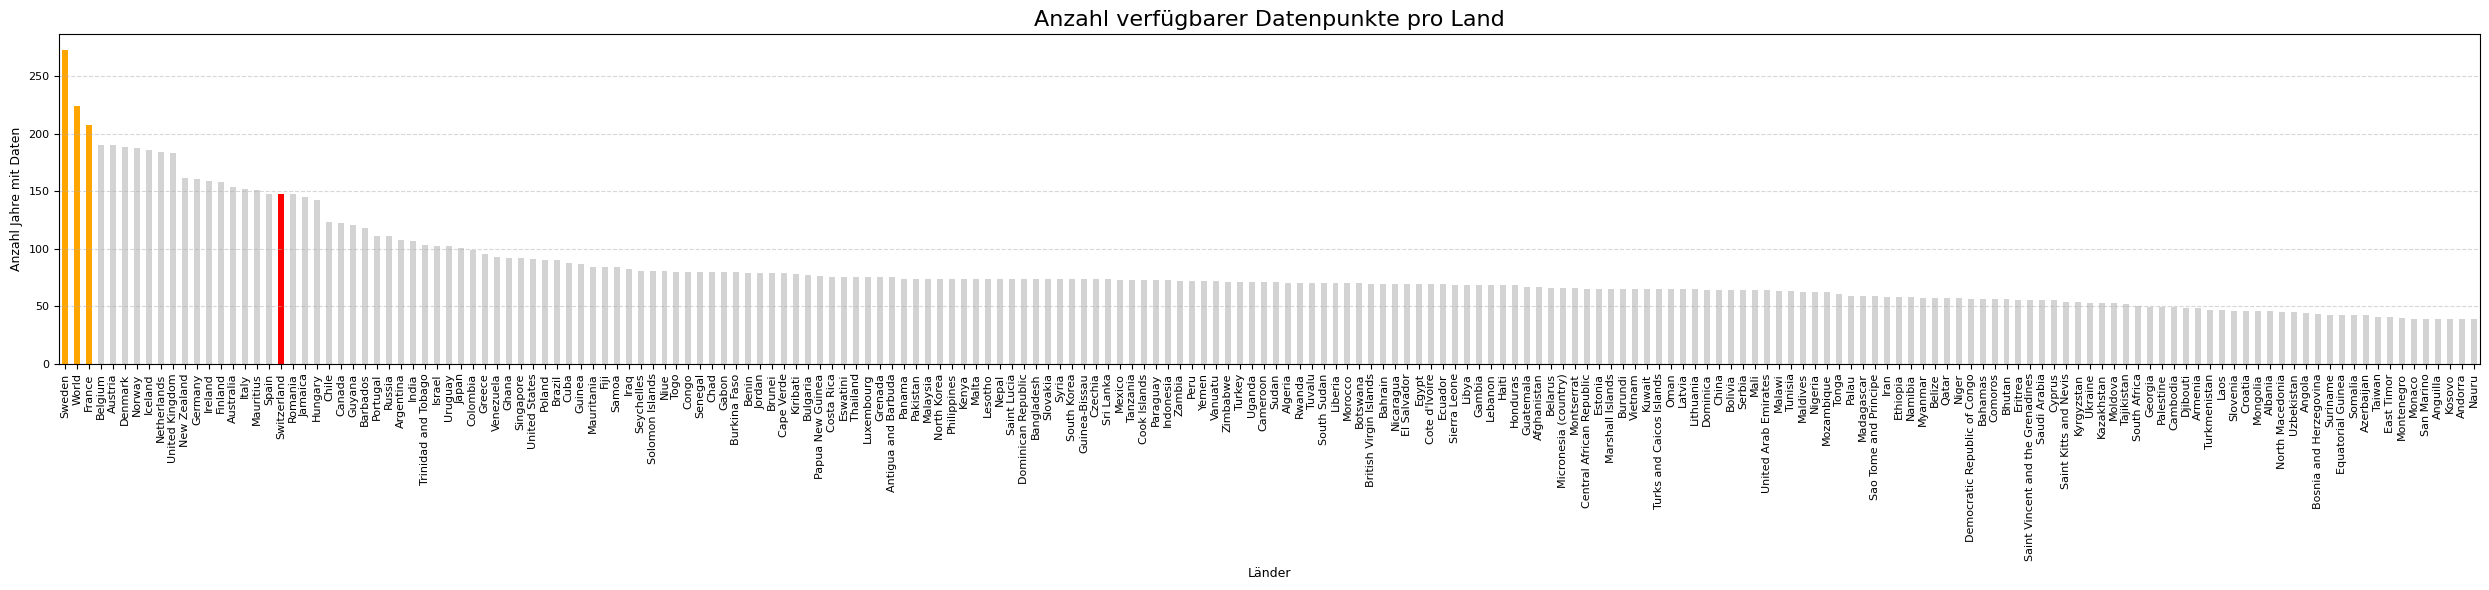

In [195]:
import matplotlib.pyplot as plt

# Basisdaten: Länder mit Anzahl gültiger Werte
df_länder = df[df["Ebene"] == "Land"]
datenpunkte = df_länder.groupby("Land")["Kindersterblichkeit"].apply(lambda x: x.notna().sum())
datenpunkte = datenpunkte.sort_values(ascending=False)

# Konfiguration
figsize = (25, 6)             # Größe der Grafik (Breite, Höhe in Zoll)
bar_width = 0.5              # Breite der Balken (0.1 – 1.0)
fontsize_title = 16
fontsize_labels = 9
fontsize_ticks = 8

farbe_standard = "lightgrey"
farbe_top3 = "orange"
farbe_schweiz = "red"

# Farben setzen
farben = [farbe_standard] * len(datenpunkte)
top3 = datenpunkte.head(3).index

for i, land in enumerate(datenpunkte.index):
    if land in top3:
        farben[i] = farbe_top3
    elif land == "Switzerland":
        farben[i] = farbe_schweiz

# Plot
plt.figure(figsize=figsize)
plt.bar(datenpunkte.index, datenpunkte.values, color=farben, width=bar_width)

plt.xlim(-0.5, len(datenpunkte) - 0.5)

plt.title("Anzahl verfügbarer Datenpunkte pro Land", fontsize=fontsize_title)
plt.ylabel("Anzahl Jahre mit Daten", fontsize=fontsize_labels)
plt.xlabel("Länder", fontsize=fontsize_labels)

plt.xticks(rotation=90, fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


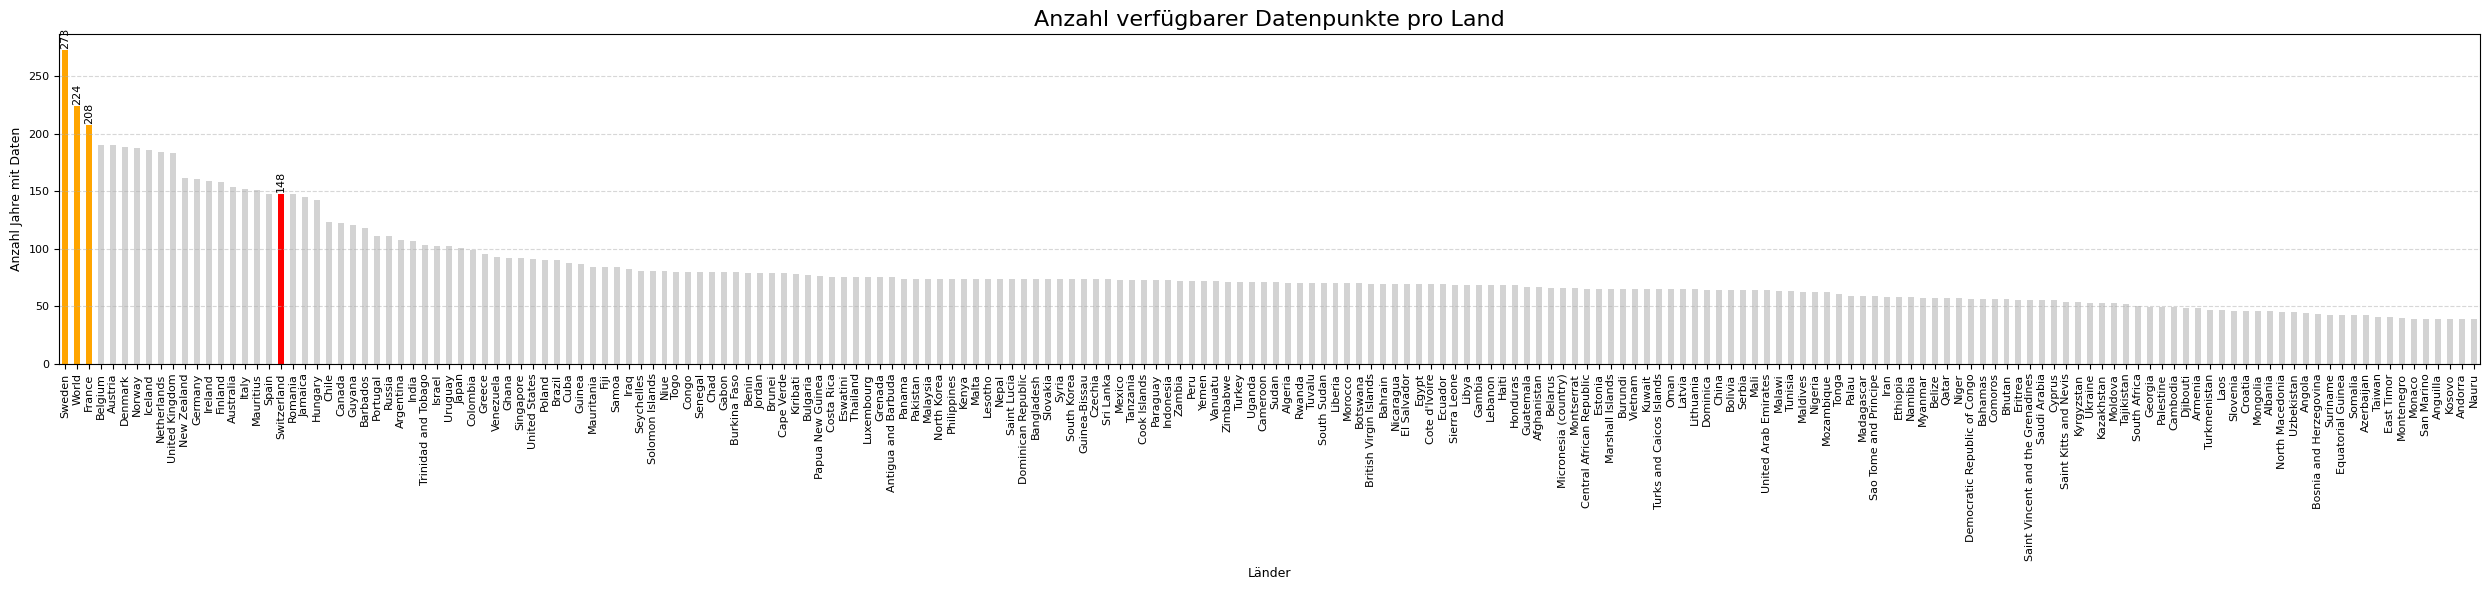

In [196]:
import matplotlib.pyplot as plt

# Basisdaten: Länder mit Anzahl gültiger Werte
df_länder = df[df["Ebene"] == "Land"]
datenpunkte = df_länder.groupby("Land")["Kindersterblichkeit"].apply(lambda x: x.notna().sum())
datenpunkte = datenpunkte.sort_values(ascending=False)

# Konfiguration
figsize = (25, 6)
bar_width = 0.5
fontsize_title = 16
fontsize_labels = 9
fontsize_ticks = 8  # Wird auch für Balkenbeschriftung verwendet

farbe_standard = "lightgrey"
farbe_top3 = "orange"
farbe_schweiz = "red"

# Farben zuweisen
farben = [farbe_standard] * len(datenpunkte)
top3 = datenpunkte.head(3).index

for i, land in enumerate(datenpunkte.index):
    if land in top3:
        farben[i] = farbe_top3
    elif land == "Switzerland":
        farben[i] = farbe_schweiz

# Plot
plt.figure(figsize=figsize)
bars = plt.bar(datenpunkte.index, datenpunkte.values, color=farben, width=bar_width)

plt.xlim(-0.5, len(datenpunkte) - 0.5)
plt.title("Anzahl verfügbarer Datenpunkte pro Land", fontsize=fontsize_title)
plt.ylabel("Anzahl Jahre mit Daten", fontsize=fontsize_labels)
plt.xlabel("Länder", fontsize=fontsize_labels)

plt.xticks(rotation=90, fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Werte über den Top 3 + Schweiz anzeigen (rot/orange Balken)
for i, bar in enumerate(bars):
    land = datenpunkte.index[i]
    wert = datenpunkte.iloc[i]
    
    if land in top3 or land == "Switzerland":
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1,  # etwas oberhalb des Balkens
            str(wert),
            ha='center',
            va='bottom',
            fontsize=fontsize_ticks,
            rotation=90,
            color='black'
        )

plt.tight_layout()
plt.show()
